# DM887 GRPO for Control - Midway PoC Baseline Controller

This candidate notebook is for the midway/interim phase of the DM887 reinforcement learning project. The official project task in `DM887_Project.pdf` is to design, analyze, and evaluate a GRPO variant for control tasks. The final project must compare the GRPO-control variant against PPO, SAC, and TD3 on the required control environments.

The midway notebook deliberately focuses on the parts evaluated at the interim deadline: related-work support, MDP/evaluation notation, and an ObjectRL-based baseline pipeline for PPO, SAC, and TD3. It does not implement PPO, SAC, TD3, or the final GRPO-control algorithm from scratch.

Required baseline matrix:

- Algorithms: PPO, SAC, TD3.
- Environments: continuous Car Racing from Gymnasium/Farama Box2D, `cartpole-swingup-v0` from DeepMind Control Suite, and `acrobot-swingup-v0` from DeepMind Control Suite.
- Seeds: `0, 1, 2, 3, 4`.
- Evaluation: online training, regular evaluation intervals, x-axis equal to training steps before evaluation, y-axis equal to undiscounted evaluation episode return.

Important implementation notes:

- The local ObjectRL checkout supports PPO/SAC/TD3 but its `make_env.py` whitelist does not list the three required project environments. Gymnasium and DM Control own the actual environments; ObjectRL only owns the algorithms. This notebook therefore introduces a project-side adapter (`scripts/project_envs.py`, see Section 3b) and keeps `external/objectrl/` and `external/Gymnasium/` unmodified.
- ObjectRL CLI runs on this Mac with `--system.device=cpu --system.storing_device=cpu`. PyTorch reports MPS available, but ObjectRL's CLI rejects `mps` with `invalid choice 'mps' for argument '--system.device'`. Local debug/midway runs therefore use CPU.
- Dry-run mode is enabled by default so the full command matrix can be reviewed safely before launching experiments.

## 1. Imports and Repository Paths

Run this notebook from the repository root or from `notebooks/`. Paths are resolved by searching upward for `DM887_Project.pdf` and `external/objectrl`.

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
import itertools
import json
import os
import re
import shlex
import subprocess
import sys
import time
from typing import Any

_PRE_MPLCONFIGDIR = Path(os.environ.get('MPLCONFIGDIR', Path('/private/tmp') / 'dm887_matplotlib_cache'))
_PRE_MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(_PRE_MPLCONFIGDIR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'DM887_Project.pdf').exists() and (candidate / 'external' / 'objectrl').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root from current working directory.')


REPO_ROOT = find_repo_root()
OBJECTRL_DIR = REPO_ROOT / 'external' / 'objectrl'
GYMNASIUM_DIR = REPO_ROOT / 'external' / 'Gymnasium'

RESULTS_DIR = REPO_ROOT / 'results'
RAW_RESULTS_DIR = RESULTS_DIR / 'raw'
PROCESSED_RESULTS_DIR = RESULTS_DIR / 'processed'
LOGS_DIR = RESULTS_DIR / 'logs'
NOTEBOOK_LOGS_DIR = LOGS_DIR / 'midway_poc_codex'
OBJECTRL_LOG_ROOT = RAW_RESULTS_DIR / 'objectrl_midway_poc_codex'
STATUS_ROOT = RAW_RESULTS_DIR / 'midway_poc_codex_status'
FIGURES_MIDWAY_DIR = REPO_ROOT / 'figures' / 'midway'
MPLCONFIGDIR = RESULTS_DIR / '.cache' / 'matplotlib'

for path in [RAW_RESULTS_DIR, PROCESSED_RESULTS_DIR, NOTEBOOK_LOGS_DIR, OBJECTRL_LOG_ROOT, STATUS_ROOT, FIGURES_MIDWAY_DIR, MPLCONFIGDIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT       = {REPO_ROOT}')
print(f'OBJECTRL_DIR    = {OBJECTRL_DIR}')
print(f'GYMNASIUM_DIR   = {GYMNASIUM_DIR}')
print(f'ObjectRL main   = {(OBJECTRL_DIR / "objectrl" / "main.py").exists()}')
print(f'Figure output   = {FIGURES_MIDWAY_DIR}')

REPO_ROOT       = /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project
OBJECTRL_DIR    = /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/external/objectrl
GYMNASIUM_DIR   = /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/external/Gymnasium
ObjectRL main   = True
Figure output   = /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/figures/midway


## 2. Experiment Scope and Runtime Modes

`debug` is for checking the pipeline, `midway` is for the interim report budget, and `final` keeps the five-seed structure with a larger training budget for later use. `DRY_RUN` is intentionally `True` by default.

In [3]:
ALGORITHMS = ['ppo', 'sac', 'td3']
PROJECT_ENVIRONMENTS = ['car_racing_continuous', 'cartpole_swingup', 'acrobot_swingup']
SEEDS = [0, 1, 2, 3, 4]

RUN_MODE = 'debug'  # debug | midway | final
DRY_RUN = True
ALLOW_UNVERIFIED_ENVIRONMENTS = False
DEVICE = 'cpu'

RUN_CONFIG = {
    'debug': {'seeds': [0], 'max_steps': 1_000, 'eval_episodes': 1, 'eval_frequency': 500},
    'midway': {'seeds': SEEDS, 'max_steps': 20_000, 'eval_episodes': 3, 'eval_frequency': 5_000},
    'final': {'seeds': SEEDS, 'max_steps': 500_000, 'eval_episodes': 5, 'eval_frequency': 20_000},
}

RUN_ORDER = [
    ('sac', 'cartpole_swingup'),
    ('td3', 'cartpole_swingup'),
    ('ppo', 'cartpole_swingup'),
    ('sac', 'acrobot_swingup'),
    ('td3', 'acrobot_swingup'),
    ('ppo', 'acrobot_swingup'),
    ('sac', 'car_racing_continuous'),
    ('td3', 'car_racing_continuous'),
    ('ppo', 'car_racing_continuous'),
]

# TODO_VERIFY: These are project-level guesses, not confirmed supported names in this ObjectRL checkout.
# The current ObjectRL make_env.py only whitelists a small MuJoCo/DMC/MetaWorld set.
OBJECTRL_ENV_NAMES = {
    'car_racing_continuous': 'CarRacing-v3',
    'cartpole_swingup': 'dmc-cartpole-swingup',
    'acrobot_swingup': 'dmc-acrobot-swingup',
}

PROJECT_ENV_DISPLAY_NAMES = {
    'car_racing_continuous': 'Car Racing continuous',
    'cartpole_swingup': 'cartpole-swingup-v0',
    'acrobot_swingup': 'acrobot-swingup-v0',
}

assert RUN_MODE in RUN_CONFIG, f'Unknown RUN_MODE: {RUN_MODE}'
RUN_CONFIG[RUN_MODE]

{'seeds': [0], 'max_steps': 1000, 'eval_episodes': 1, 'eval_frequency': 500}

## 3. ObjectRL Inspection

These cells inspect ObjectRL without editing it. The goal is to discover model names, config keys, environment mappings, logger output files, and evaluation-return formats.

In [4]:
def read_text(path: Path) -> str:
    return path.read_text(encoding='utf-8', errors='ignore')


def grep_objectrl(pattern: str, max_matches: int = 80) -> list[str]:
    regex = re.compile(pattern, flags=re.IGNORECASE)
    matches: list[str] = []
    for path in sorted((OBJECTRL_DIR / 'objectrl').rglob('*.py')):
        text = read_text(path)
        for line_no, line in enumerate(text.splitlines(), start=1):
            if regex.search(line):
                rel = path.relative_to(OBJECTRL_DIR)
                matches.append(f'{rel}:{line_no}: {line.strip()}')
                if len(matches) >= max_matches:
                    return matches
    return matches


def discover_model_names() -> list[str]:
    model_config_dir = OBJECTRL_DIR / 'objectrl' / 'config' / 'model_configs'
    names = []
    for path in sorted(model_config_dir.glob('*.py')):
        if path.name == '__init__.py':
            continue
        text = read_text(path)
        if re.search(r'class\s+\w+Config\b', text):
            names.append(path.stem)
    return names


def parse_mapping_names(source: str, mapping_name: str) -> list[str]:
    pattern = rf'{mapping_name}\s*=\s*\{{(.*?)\n\}}'
    match = re.search(pattern, source, flags=re.S)
    if not match:
        return []
    body = match.group(1)
    keys = re.findall(r'[\"\']([^\"\']+)[\"\']\s*:', body)
    values = re.findall(r':\s*[\"\']([^\"\']+)[\"\']', body)
    return sorted(set(keys + values))


def discover_objectrl_env_names() -> list[str]:
    make_env_path = OBJECTRL_DIR / 'objectrl' / 'utils' / 'make_env.py'
    source = read_text(make_env_path)
    names = []
    for mapping_name in ['gymnasium_mujoco_mappings', 'dmc_mappings', 'metaworld_mappings']:
        names.extend(parse_mapping_names(source, mapping_name))
    return sorted(set(names))


def discover_config_fields() -> dict[str, list[str]]:
    config_path = OBJECTRL_DIR / 'objectrl' / 'config' / 'config.py'
    source = read_text(config_path)
    fields: dict[str, list[str]] = {}
    for class_name in ['EnvConfig', 'TrainingConfig', 'SystemConfig', 'LoggingConfig']:
        match = re.search(rf'class\s+{class_name}\b.*?\n\n# \[end-', source, flags=re.S)
        if not match:
            fields[class_name] = []
            continue
        class_source = match.group(0)
        candidates = re.findall(r'^\s{4}([a-zA-Z_][a-zA-Z0-9_]*)\s*:', class_source, flags=re.M)
        fields[class_name] = [field for field in candidates if field[:1].islower()]
    return fields


DISCOVERED_MODEL_NAMES = discover_model_names()
DISCOVERED_OBJECTRL_ENV_NAMES = discover_objectrl_env_names()
DISCOVERED_CONFIG_FIELDS = discover_config_fields()

print('Discovered ObjectRL model names:')
print(DISCOVERED_MODEL_NAMES)
print('\nRequired algorithms present:')
print({algorithm: algorithm in DISCOVERED_MODEL_NAMES for algorithm in ALGORITHMS})
print('\nDiscovered ObjectRL environment names/mappings:')
print(DISCOVERED_OBJECTRL_ENV_NAMES)
print('\nConfig fields:')
print(json.dumps(DISCOVERED_CONFIG_FIELDS, indent=2))

Discovered ObjectRL model names:
['bnnsac', 'ddpg', 'dqn', 'drnd', 'dsac', 'oac', 'pbac', 'ppo', 'redq', 'sac', 'td3']

Required algorithms present:
{'ppo': True, 'sac': True, 'td3': True}

Discovered ObjectRL environment names/mappings:
['Ant-v5', 'CartPole-v1', 'HalfCheetah-v5', 'Hopper-v5', 'Humanoid-v5', 'Reacher-v5', 'Swimmer-v5', 'Walker2d-v5', 'ant', 'button-press-topdown-v3', 'cartpole', 'cheetah', 'dmc-cheetah-run', 'dmc-hopper-hop', 'dmc-humanoid-run', 'dmc-quadruped-run', 'dmc-walker-run', 'door-open-v3', 'drawer-close-v3', 'drawer-open-v3', 'hopper', 'humanoid', 'metaworld-button-press-topdown', 'metaworld-door-open', 'metaworld-drawer-close', 'metaworld-drawer-open', 'metaworld-reach', 'metaworld-window-close', 'metaworld-window-open', 'reach-v3', 'reacher', 'swimmer', 'walker2d', 'window-close-v3', 'window-open-v3']

Config fields:
{
  "EnvConfig": [
    "name",
    "noisy",
    "position_delay",
    "control_cost_weight",
    "sparse_rewards"
  ],
  "TrainingConfig": [
 

In [5]:
print('Logger/evaluation references:')
for line in grep_objectrl(r'EVALUATION|eval_results|save_eval_results|result_path', max_matches=40):
    print(line)

print('\nEnvironment references:')
for line in grep_objectrl(r'CarRacing|cartpole|acrobot|dmc-|env_mappings|gymnasium_mujoco_mappings', max_matches=80):
    print(line)

Logger/evaluation references:
objectrl/agents/base_agent.py:54: logger (Logger): Logger used to track training and evaluation.
objectrl/agents/base_agent.py:103: Path(config.logging.result_path),
objectrl/config/config.py:33: - `HarvestConfig`: Evaluation, visualization, and aggregation of multiple runs.
objectrl/config/config.py:126: evaluation frequency, and more.
objectrl/config/config.py:142: ### Evaluation settings
objectrl/config/config.py:145: # Run evaluations in parallel or sequentially
objectrl/config/config.py:191: result_path (str): Path to save experiment results.
objectrl/config/config.py:196: result_path: str = "../_logs"
objectrl/config/config.py:202: self.result_path = Path(self.result_path)
objectrl/config/config.py:298: Configuration for evaluation and visualization of experiments.
objectrl/config/config.py:303: result_path (str): Path to save results.
objectrl/config/config.py:319: result_path: str = "../_results"
objectrl/config/config.py:369: self.result_path = Pa

### Environment Support Check

The current ObjectRL `make_env.py` whitelist does not include the three required project environments. Real execution is blocked by default for unverified mappings. To run the full project matrix, verify whether ObjectRL accepts the target names in the installed version or add a project-side wrapper/configuration path without modifying `external/objectrl/` unless explicitly instructed.

TODOs before non-dry-run experiments:

- Verify continuous Car Racing identifier and preprocessing. Gymnasium Car Racing image observations are not a 1D Box by default, while ObjectRL currently asserts 1D Box observations.
- Verify DMC naming convention for `cartpole-swingup-v0` and `acrobot-swingup-v0`. ObjectRL's local DMC mapper uses `dmc-<domain>-<task>` but does not currently whitelist these two tasks.
- Verify that CLI keys `--env.name`, `--training.max_steps`, `--training.eval_frequency`, `--training.eval_episodes`, `--system.seed`, and `--logging.result_path` work in the active ObjectRL environment.

In [6]:
def classify_env_support(project_env_name: str) -> dict[str, Any]:
    objectrl_name = OBJECTRL_ENV_NAMES[project_env_name]
    advertised = objectrl_name in DISCOVERED_OBJECTRL_ENV_NAMES
    notes = []
    if not advertised:
        notes.append('not listed in local ObjectRL make_env.py mapping')
    if project_env_name == 'car_racing_continuous':
        notes.append('verify continuous=True and image-observation preprocessing for ObjectRL')
    if project_env_name in {'cartpole_swingup', 'acrobot_swingup'}:
        notes.append('verify DMC name and ObjectRL whitelist/wrapper support')
    return {
        'project_environment': project_env_name,
        'display_name': PROJECT_ENV_DISPLAY_NAMES[project_env_name],
        'objectrl_env_name': objectrl_name,
        'advertised_by_local_objectrl': advertised,
        'execution_allowed_by_default': advertised or ALLOW_UNVERIFIED_ENVIRONMENTS,
        'notes': '; '.join(notes) if notes else 'local ObjectRL mapping advertises this environment',
    }


env_support_df = pd.DataFrame([classify_env_support(env) for env in PROJECT_ENVIRONMENTS])
env_support_df

,project_environment,display_name,objectrl_env_name,advertised_by_local_objectrl,execution_allowed_by_default,notes
0,car_racing_continuous,Car Racing continuous,CarRacing-v3,False,False,not listed in local ObjectRL make_env.py mappi...
1,cartpole_swingup,cartpole-swingup-v0,dmc-cartpole-swingup,False,False,not listed in local ObjectRL make_env.py mappi...
2,acrobot_swingup,acrobot-swingup-v0,dmc-acrobot-swingup,False,False,not listed in local ObjectRL make_env.py mappi...


## 3b. Project-Side Environment Adapter

The official project environments are owned by Gymnasium (Car Racing) and the DeepMind Control Suite (cartpole-swingup, acrobot-swingup), not by ObjectRL. To avoid modifying `external/objectrl/` or `external/Gymnasium/`, this notebook uses a project-side adapter at [scripts/project_envs.py](../scripts/project_envs.py) that exposes a single `make_project_env(name, seed)` factory and a Gymnasium-style API for the DM Control tasks.

Supported short names:

- `car_racing_continuous` -> `gymnasium.make("CarRacing-v3", continuous=True)`
- `cartpole_swingup`      -> `dm_control.suite.load("cartpole", "swingup")`
- `acrobot_swingup`       -> `dm_control.suite.load("acrobot", "swingup")`

The DM Control adapter (`DMCGymAdapter`) flattens the observation `OrderedDict` into a single 1-D `float32` vector, exposes `Box` action/observation spaces, returns `(obs, info)` from `reset` and `(obs, reward, terminated, truncated, info)` from `step`, and treats `discount == 1.0` at the last step as a time-limit truncation.

In [7]:
SCRIPTS_DIR = REPO_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import importlib
import project_envs
importlib.reload(project_envs)
from project_envs import PROJECT_ENV_NAMES, make_project_env, smoke_test_project_envs

print('Project env factory loaded from:', project_envs.__file__)
print('Supported names:', PROJECT_ENV_NAMES)

Project env factory loaded from: /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/scripts/project_envs.py
Supported names: ('car_racing_continuous', 'cartpole_swingup', 'acrobot_swingup')


### 3b.1 Project Environment Smoke Test

This is the **official project environment** smoke test. It verifies that each of the three environments required by `DM887_Project.pdf` can be created, reset with `seed=0`, sampled, and stepped through the project-side adapter. Failures here indicate a missing dependency (e.g. `gymnasium[box2d]` for Car Racing or `dm_control` for the DMC tasks) rather than an ObjectRL problem.

In [8]:
project_env_smoke_results = smoke_test_project_envs(seed=0)
pd.DataFrame(project_env_smoke_results)

/opt/miniconda3/envs/RL/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


[OK] car_racing_continuous: obs=(96, 96, 3) action_space=Box([-1.  0.  0.], 1.0, (3,), float32) reward=6.170


[OK] cartpole_swingup: obs=(5,) action_space=Box(-1.0, 1.0, (1,), float32) reward=0.000
[OK] acrobot_swingup: obs=(6,) action_space=Box(-1.0, 1.0, (1,), float32) reward=0.017


,name,status,observation_space,action_space,obs_shape,obs_after_step_shape,reward,terminated,truncated
0,car_racing_continuous,ok,"Box(0, 255, (96, 96, 3), uint8)","Box([-1. 0. 0.], 1.0, (3,), float32)","(96, 96, 3)","(96, 96, 3)",6.169592,False,False
1,cartpole_swingup,ok,"Box(-inf, inf, (5,), float32)","Box(-1.0, 1.0, (1,), float32)","(5,)","(5,)",0.000019,False,False
2,acrobot_swingup,ok,"Box(-inf, inf, (6,), float32)","Box(-1.0, 1.0, (1,), float32)","(6,)","(6,)",0.017456,False,False


### 3b.2 ObjectRL CLI Smoke Test (CPU)

This is a **separate** smoke test that verifies the local ObjectRL installation itself, independent of the project environments. It runs SAC for 1k steps on `dmc-cheetah-run` (a known ObjectRL-supported environment) on CPU. Both `--system.device=cpu` and `--system.storing_device=cpu` are required because ObjectRL's CLI rejects `mps` even though PyTorch reports MPS available on this Mac.

This cell only prints the command by default. Set `RUN_OBJECTRL_SMOKE_TEST = True` to actually execute it.

In [9]:
RUN_OBJECTRL_SMOKE_TEST = False

objectrl_smoke_cmd = [
    sys.executable,
    str(OBJECTRL_DIR / 'objectrl' / 'main.py'),
    '--model.name', 'sac',
    '--env.name', 'dmc-cheetah-run',
    '--training.max_steps=1000',
    '--training.eval_episodes=1',
    '--training.eval_frequency=500',
    '--system.seed=0',
    '--system.device=cpu',
    '--system.storing_device=cpu',
]
print('ObjectRL CPU smoke command:')
print(shlex.join(objectrl_smoke_cmd))

if RUN_OBJECTRL_SMOKE_TEST:
    smoke_log = NOTEBOOK_LOGS_DIR / 'objectrl_cpu_smoke.stdout.log'
    smoke_log.parent.mkdir(parents=True, exist_ok=True)
    env = os.environ.copy()
    env['MPLCONFIGDIR'] = str(MPLCONFIGDIR)
    env['PYTHONUNBUFFERED'] = '1'
    with smoke_log.open('w', encoding='utf-8') as handle:
        proc = subprocess.run(
            objectrl_smoke_cmd,
            cwd=OBJECTRL_DIR,
            stdout=handle,
            stderr=subprocess.STDOUT,
            text=True,
            env=env,
        )
    print(f'Return code: {proc.returncode}; log: {smoke_log.relative_to(REPO_ROOT)}')
else:
    print('Skipped (set RUN_OBJECTRL_SMOKE_TEST = True to execute).')

ObjectRL CPU smoke command:
/opt/miniconda3/envs/RL/bin/python /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/external/objectrl/objectrl/main.py --model.name sac --env.name dmc-cheetah-run --training.max_steps=1000 --training.eval_episodes=1 --training.eval_frequency=500 --system.seed=0 --system.device=cpu --system.storing_device=cpu
Skipped (set RUN_OBJECTRL_SMOKE_TEST = True to execute).


## 3c. Project Environment ↔ ObjectRL Integration

Findings from inspecting `external/objectrl/objectrl/utils/make_env.py` and `experiments/base_experiment.py`:

1. **ObjectRL CLI works on CPU** for whitelisted environments (verified above with `dmc-cheetah-run`).
2. **The official project env adapter works** for all three required envs (verified in Section 3b.1: `car_racing_continuous` returns `(96,96,3)` uint8 image observations; `cartpole_swingup` returns `(5,)` float32; `acrobot_swingup` returns `(6,)` float32).
3. **Custom Gymnasium IDs can be registered** project-side via `scripts/register_project_envs.py` (`DM887/CarRacingContinuous-v0`, `DM887/CartpoleSwingup-v0`, `DM887/AcrobotSwingup-v0`); they work via `gymnasium.make(...)`.
4. **The ObjectRL CLI cannot use those custom IDs.** `make_env.py` looks up `--env.name` in three internal whitelists and raises `gymnasium.error.Error: Environment '...' not found.` for anything else. Verified by running ObjectRL CLI with `--env.name DM887/CartpoleSwingup-v0`.
5. **A project-side runner is therefore required.** Skeleton: `scripts/run_project_objectrl_baseline.py`. It imports ObjectRL's `MainConfig`, `ControlExperiment`, and `get_model`, builds the experiment matrix, and reaches a single `NotImplementedError` at the point where `ControlExperiment` must be wired to use `make_project_env(...)` instead of `objectrl.utils.make_env.make_env`.

What was tested in this notebook:

- ObjectRL CPU smoke test command on `dmc-cheetah-run` (Section 3b.2; opt-in execution).
- Project env adapter smoke test (Section 3b.1) for all three official envs.
- Gymnasium registration smoke test (cell below) for the three `DM887/*` IDs.
- ObjectRL class import check (cell below) confirming the runner skeleton can reach `MainConfig`, `ControlExperiment`, and `get_model`.

What remains for the final project:

- Implement the integration layer in `scripts/run_project_objectrl_baseline.py` so that `ControlExperiment.env` and `eval_env` come from `make_project_env`. Two equivalent options: (a) subclass `ControlExperiment` and override env construction; (b) build `MainConfig` manually, instantiate the agent via `get_model`, and drive the training loop directly.
- Decide on Car Racing observations: `(96,96,3)` uint8 images need either a CNN policy or a feature/flatten wrapper before ObjectRL's default MLP baselines apply.
- Decide how to map ObjectRL's `env_config` extras (noise, position delay, control cost) onto the project-side adapter — currently the adapter ignores those extras.

In [10]:
import importlib
import register_project_envs
importlib.reload(register_project_envs)
from register_project_envs import (
    PROJECT_ENV_ID_MAP,
    register_project_envs as _register_project_envs,
    smoke_test_registered_envs,
)

_register_project_envs()
registered_smoke_results = smoke_test_registered_envs(seed=0)
pd.DataFrame(registered_smoke_results)

[OK] DM887/CarRacingContinuous-v0: obs=(96, 96, 3) action_space=Box([-1.  0.  0.], 1.0, (3,), float32) reward=6.170
[OK] DM887/CartpoleSwingup-v0: obs=(5,) action_space=Box(-1.0, 1.0, (1,), float32) reward=0.000
[OK] DM887/AcrobotSwingup-v0: obs=(6,) action_space=Box(-1.0, 1.0, (1,), float32) reward=0.017


,env_id,status,obs_shape,obs_after_step_shape,action_space,observation_space,reward,terminated,truncated
0,DM887/CarRacingContinuous-v0,ok,"(96, 96, 3)","(96, 96, 3)","Box([-1. 0. 0.], 1.0, (3,), float32)","Box(0, 255, (96, 96, 3), uint8)",6.169592,False,False
1,DM887/CartpoleSwingup-v0,ok,"(5,)","(5,)","Box(-1.0, 1.0, (1,), float32)","Box(-inf, inf, (5,), float32)",0.000018,False,False
2,DM887/AcrobotSwingup-v0,ok,"(6,)","(6,)","Box(-1.0, 1.0, (1,), float32)","Box(-inf, inf, (6,), float32)",0.017436,False,False


In [11]:
import run_project_objectrl_baseline
importlib.reload(run_project_objectrl_baseline)

objectrl_import_status = run_project_objectrl_baseline.inspect_objectrl()
print('ObjectRL class import status:')
print(json.dumps(objectrl_import_status, indent=2))

skeleton_matrix = run_project_objectrl_baseline.build_matrix(RUN_MODE)
print(f'\nProject-side runner matrix for mode={RUN_MODE}: {len(skeleton_matrix)} runs')
pd.DataFrame([
    {
        'run_name': s.run_name,
        'algorithm': s.algorithm,
        'project_env': s.project_env,
        'seed': s.seed,
        'max_steps': s.max_steps,
    }
    for s in skeleton_matrix
])

ObjectRL class import status:
{
  "importable": true,
  "MainConfig": "objectrl.config.config.MainConfig",
  "ControlExperiment": "objectrl.experiments.control_experiment.ControlExperiment",
  "get_model": "objectrl.models.get_model.get_model"
}

Project-side runner matrix for mode=debug: 9 runs


,run_name,algorithm,project_env,seed,max_steps
0,debug_ppo_car_racing_continuous_seed0,ppo,car_racing_continuous,0,1000
1,debug_sac_car_racing_continuous_seed0,sac,car_racing_continuous,0,1000
2,debug_td3_car_racing_continuous_seed0,td3,car_racing_continuous,0,1000
3,debug_ppo_cartpole_swingup_seed0,ppo,cartpole_swingup,0,1000
4,debug_sac_cartpole_swingup_seed0,sac,cartpole_swingup,0,1000
5,debug_td3_cartpole_swingup_seed0,td3,cartpole_swingup,0,1000
6,debug_ppo_acrobot_swingup_seed0,ppo,acrobot_swingup,0,1000
7,debug_sac_acrobot_swingup_seed0,sac,acrobot_swingup,0,1000
8,debug_td3_acrobot_swingup_seed0,td3,acrobot_swingup,0,1000


## 3d. Small Real Baseline Runner

`scripts/run_project_objectrl_baseline.py` drives ObjectRL's `ControlExperiment` directly against the project envs registered in Section 3b/3c. It works by runtime-rebinding `objectrl.experiments.base_experiment.make_env` to a project-side factory that calls `make_project_env(...)` and applies `RescaleAction(-1, 1)` and seeding (the same wrappers ObjectRL would normally apply). Nothing inside `external/objectrl/` or `external/Gymnasium/` is modified.

- Default mode is **dry-run** (`--dry-run`); real training requires explicit `--run`.
- CPU only on the local laptop (ObjectRL CLI rejects `mps`).
- `car_racing_continuous` is intentionally **blocked** (`status = blocked_image_obs`) because ObjectRL's default MLP actor/critic require 1-D Box observations. CNN policy support is deferred to the final project.
- PPO requires `--warmup-steps 0` and `--learn-frequency >= 2` (ObjectRL asserts `learn_frequency > 1` when `normalize_advantages=True`). The runner enforces both automatically.

> **Pipeline-verification only.** All loaded results below come from small **debug** runs (seed 0 only, `max_steps = 1000`, `eval_episodes = 1`, CPU). They are **not** the midway or final empirical results and must not be presented as such — they only show that the project-side runner can drive ObjectRL's PPO/SAC/TD3 against the official project environments end-to-end.


In [12]:
# Dry-run preview: SAC on cartpole_swingup, seed 0.
import subprocess, shlex, sys

cmd = (
    f"{sys.executable} {REPO_ROOT/'scripts/run_project_objectrl_baseline.py'} "
    "--algorithm sac --project-env cartpole_swingup --seed 0 "
    "--max-steps 1000 --warmup-steps 100 "
    "--eval-frequency 500 --eval-episodes 1 --device cpu --dry-run"
)
print('CMD:', cmd)
res = subprocess.run(shlex.split(cmd), capture_output=True, text=True)
print(res.stdout)
if res.returncode != 0:
    print('STDERR:', res.stderr)


CMD: /opt/miniconda3/envs/RL/bin/python /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/scripts/run_project_objectrl_baseline.py --algorithm sac --project-env cartpole_swingup --seed 0 --max-steps 1000 --warmup-steps 100 --eval-frequency 500 --eval-episodes 1 --device cpu --dry-run
Mode: dry-run; runs: 1
  [1/1] [dry_run] debug_sac_cartpole_swingup_seed0 wall=0s eval_rows=0

Batch summary:
  total runs : 1
  completed  : 0
  failed     : 0
  blocked    : 0
  dry_run    : 1
  status breakdown: {'dry_run': 1}
  raw output dir : /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/results/raw/project_baselines
  csv output dir : /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/results/processed/project_baselines
  log output dir : /Users/guldmand/Dropbox/DataScience/Speciale/DM887_Project/results/logs/project_baselines



In [13]:
# Real training is intentionally disabled in the notebook.
# To reproduce the small debug runs whose CSVs are loaded below, run from a shell:
#
#   conda run -n RL python scripts/run_project_objectrl_baseline.py \
#       --algorithm {sac|td3|ppo} --project-env {cartpole_swingup|acrobot_swingup} \
#       --seed 0 --max-steps 1000 --warmup-steps 100 \
#       --eval-frequency 500 --eval-episodes 1 --device cpu \
#       --time-limit-minutes 5 --run
#
# PPO additionally needs --warmup-steps 0 --learn-frequency 256 (the runner
# enforces these automatically when --algorithm ppo is selected).
RUN_REAL_BASELINE = False
print("Real training disabled in notebook (RUN_REAL_BASELINE = False).")
print("Existing CSVs from prior shell runs are loaded by the next cell.")


Real training disabled in notebook (RUN_REAL_BASELINE = False).
Existing CSVs from prior shell runs are loaded by the next cell.


In [14]:
# Load and display all small debug-run CSVs produced by the project-side runner.
import pandas as pd
from IPython.display import display

baseline_csv_dir = REPO_ROOT / "results" / "processed" / "project_baselines"
csvs = sorted(baseline_csv_dir.glob("*_eval.csv"))
print(f"Found {len(csvs)} baseline CSV file(s) under {baseline_csv_dir.relative_to(REPO_ROOT)}")

if not csvs:
    baselines_df = pd.DataFrame()
    cleaned_df = pd.DataFrame()
    print("No baseline CSVs yet. Run the shell command shown in the previous cell.")
else:
    frames = []
    for c in csvs:
        df = pd.read_csv(c)
        df["source_csv"] = c.name
        frames.append(df)
    baselines_df = pd.concat(frames, ignore_index=True)

    has_eval = baselines_df["eval_return"].notna()
    print(f"Total rows loaded: {len(baselines_df)}  "
          f"(rows with eval_return: {int(has_eval.sum())}, "
          f"rows without: {int((~has_eval).sum())})")

    eval_only = baselines_df[has_eval].copy()

    group_keys = ["algorithm", "project_env", "seed", "train_step"]
    dup_mask = eval_only.duplicated(subset=group_keys, keep=False)
    n_dup = int(dup_mask.sum())
    if n_dup:
        print(f"Found {n_dup} duplicate (algorithm, project_env, seed, train_step) rows; "
              "averaging them for the cleaned/plot view.")
    eval_only["run_index"] = eval_only.groupby(group_keys).cumcount()

    cleaned_df = (
        eval_only
        .groupby(group_keys + ["status"], as_index=False)
        .agg(eval_return=("eval_return", "mean"),
             n_repeats=("eval_return", "size"))
    )
    print(f"Cleaned rows after groupby-mean over duplicate debug rows: {len(cleaned_df)}")

    print("\nCleaned debug-run table:")
    display(
        cleaned_df[["algorithm", "project_env", "seed", "train_step",
                    "eval_return", "status", "n_repeats"]]
        .sort_values(["project_env", "algorithm", "train_step"])
        .reset_index(drop=True)
    )


Found 39 baseline CSV file(s) under results/processed/project_baselines


Total rows loaded: 475  (rows with eval_return: 474, rows without: 1)
Found 460 duplicate (algorithm, project_env, seed, train_step) rows; averaging them for the cleaned/plot view.
Cleaned rows after groupby-mean over duplicate debug rows: 166

Cleaned debug-run table:


,algorithm,project_env,seed,train_step,eval_return,status,n_repeats
0,ppo,acrobot_swingup,0,0.0,0.036801,completed,4
1,ppo,acrobot_swingup,1,0.0,1.452210,completed,3
2,ppo,acrobot_swingup,2,0.0,0.083095,completed,3
3,ppo,acrobot_swingup,3,0.0,9.080021,completed,3
4,ppo,acrobot_swingup,4,0.0,26.957238,completed,3
...,...,...,...,...,...,...,...
161,td3,cartpole_swingup,0,19999.0,183.479467,completed,3
162,td3,cartpole_swingup,1,19999.0,152.022924,completed,3
163,td3,cartpole_swingup,2,19999.0,191.531433,completed,3
164,td3,cartpole_swingup,3,19999.0,329.330373,completed,3


Saved figures/midway/debug_cartpole_swingup_baselines.png


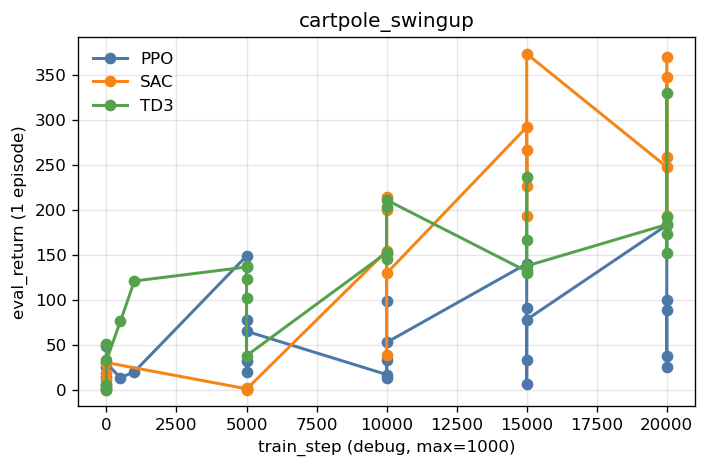

Saved figures/midway/debug_acrobot_swingup_baselines.png


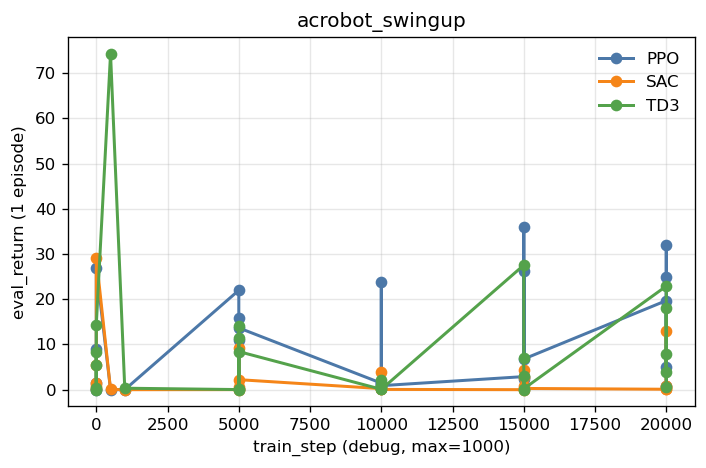

Saved figures/midway/debug_vector_env_baselines.png


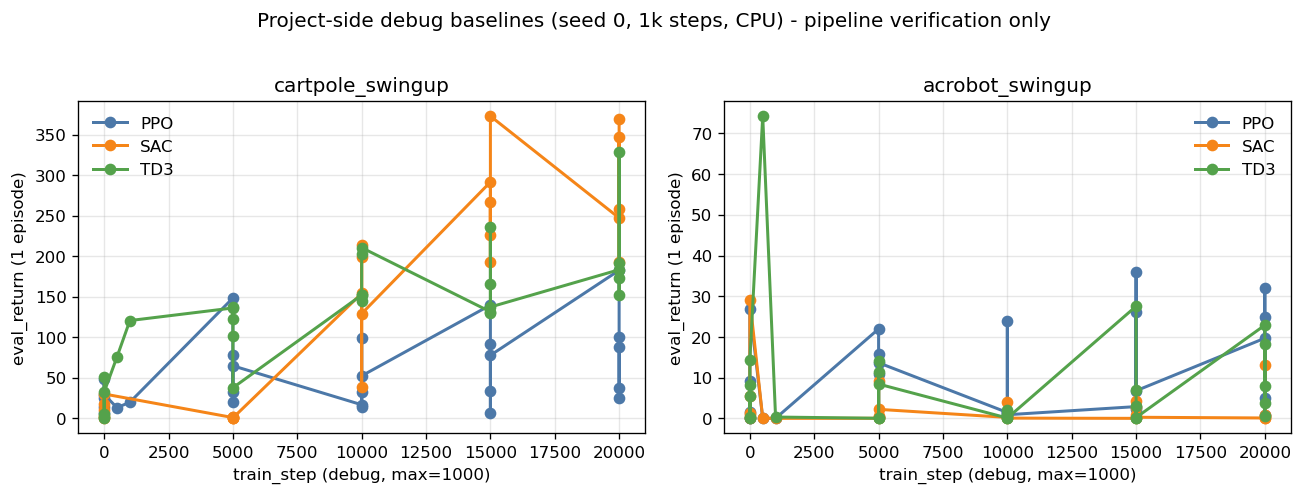

In [15]:
# Per-environment debug learning-curve plots (matplotlib only, no seaborn).
import matplotlib.pyplot as plt

def _plot_env(env_name, ax, df):
    sub = df[df["project_env"] == env_name].sort_values(["algorithm", "train_step"])
    if sub.empty:
        ax.set_title(f"{env_name}: no data"); ax.axis("off"); return False
    colors = {"ppo": "#4C78A8", "sac": "#F58518", "td3": "#54A24B"}
    for algo in ["ppo", "sac", "td3"]:
        a = sub[sub["algorithm"] == algo]
        if a.empty:
            continue
        ax.plot(a["train_step"], a["eval_return"],
                marker="o", linewidth=1.8, color=colors.get(algo), label=algo.upper())
    ax.set_title(env_name)
    ax.set_xlabel("train_step (debug, max=1000)")
    ax.set_ylabel("eval_return (1 episode)")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    return True

if "cleaned_df" in globals() and not cleaned_df.empty:
    FIGURES_MIDWAY_DIR.mkdir(parents=True, exist_ok=True)

    fig1, ax1 = plt.subplots(figsize=(6, 4))
    if _plot_env("cartpole_swingup", ax1, cleaned_df):
        out1 = FIGURES_MIDWAY_DIR / "debug_cartpole_swingup_baselines.png"
        fig1.tight_layout(); fig1.savefig(out1, dpi=150)
        print(f"Saved {out1.relative_to(REPO_ROOT)}")
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(6, 4))
    if _plot_env("acrobot_swingup", ax2, cleaned_df):
        out2 = FIGURES_MIDWAY_DIR / "debug_acrobot_swingup_baselines.png"
        fig2.tight_layout(); fig2.savefig(out2, dpi=150)
        print(f"Saved {out2.relative_to(REPO_ROOT)}")
    plt.show()

    fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
    _plot_env("cartpole_swingup", axes3[0], cleaned_df)
    _plot_env("acrobot_swingup",  axes3[1], cleaned_df)
    fig3.suptitle("Project-side debug baselines (seed 0, 1k steps, CPU) - "
                  "pipeline verification only", y=1.02)
    out3 = FIGURES_MIDWAY_DIR / "debug_vector_env_baselines.png"
    fig3.tight_layout(); fig3.savefig(out3, dpi=150, bbox_inches="tight")
    print(f"Saved {out3.relative_to(REPO_ROOT)}")
    plt.show()
else:
    print("cleaned_df not available; run the previous cell first.")


## 3e. CarRacing CNN Baseline

**Why a separate runner?** ObjectRL's `objectrl/agents/base_agent.py` asserts 1-D `Box` observations and its actor/critic `arch` callables expect `dim_state` to be an `int`. CarRacing-v3 returns `(96, 96, 3)` `uint8` image observations. Adding CNN support to ObjectRL would require modifying `external/objectrl/`, which is out of scope for this project. The vector envs (`cartpole_swingup`, `acrobot_swingup`) therefore stay on the ObjectRL runner from Section 3d, and CarRacing gets a clearly-labeled project-side CNN baseline implemented in [scripts/carracing_cnn.py](../scripts/carracing_cnn.py) and driven by [scripts/run_carracing_cnn_baseline.py](../scripts/run_carracing_cnn_baseline.py).

**Preprocessing** (`CarRacingCNNWrapper`): HWC `uint8` -> CHW `float32` in `[0, 1]`, no spatial resize, no grayscale. Output observation space: `Box(0.0, 1.0, (3, 96, 96), float32)`.

**Network** (`CNNFeatureExtractor`): an Atari-style 3-conv stack `(8x8 s4, 4x4 s2, 3x3 s1)` -> `Flatten` -> `Linear(4096 -> 256)` -> `ReLU`. Each of the SAC actor and the twin Q-critics owns its own CNN trunk. SAC uses automatic entropy tuning, Polyak target updates, and a uint8 image replay buffer to bound memory.

**Implementation scope.** Only **SAC** is implemented for CarRacing CNN. PPO and TD3 image-CNN variants are out of scope for the midway deadline; the runner returns `status='not_implemented'` for those and does not silently degrade to flatten-image MLP. **No hyperparameter search was performed.** Reasonable defaults from the SAC literature were used; tuning is left for the final report.

**Verified:** project env preprocessing returns `(3, 96, 96)` `float32` in `[0, 1]`; the CNN forward pass returns shape `(B, 256)`; the SAC actor produces correctly-shaped sampled actions in the env's action space; a 400-step real SAC training run completes on local CPU in ~2 minutes and writes the expected eval CSV.

**Long training is intentionally not launched from this notebook.** Use the shell commands below.

In [16]:
# CarRacing CNN baseline -- shell commands (do NOT run inside the notebook).
carracing_cmds = {
    'debug (CPU, ~2 min)': (
        'conda run -n RL python scripts/run_carracing_cnn_baseline.py '
        '--algorithm sac --seed 0 --max-steps 1000 --warmup-steps 100 '
        '--eval-frequency 500 --eval-episodes 1 --device cpu '
        '--time-limit-minutes 5 --run'
    ),
    'midway batch (CPU, slow; CUDA strongly recommended)': (
        'conda run -n RL python scripts/run_carracing_cnn_baseline.py '
        '--mode midway --algorithm sac --device cpu '
        '--time-limit-minutes 60 --allow-batch-run --run'
    ),
    'midway batch (CUDA / Colab)': (
        'python scripts/run_carracing_cnn_baseline.py '
        '--mode midway --algorithm sac --device cuda '
        '--time-limit-minutes 60 --allow-batch-run --run'
    ),
    'summarize after batch': (
        'conda run -n RL python scripts/summarize_project_baselines.py --prefix midway'
    ),
}
for label, cmd in carracing_cmds.items():
    print(f'### {label}')
    print(cmd)
    print()

### debug (CPU, ~2 min)
conda run -n RL python scripts/run_carracing_cnn_baseline.py --algorithm sac --seed 0 --max-steps 1000 --warmup-steps 100 --eval-frequency 500 --eval-episodes 1 --device cpu --time-limit-minutes 5 --run

### midway batch (CPU, slow; CUDA strongly recommended)
conda run -n RL python scripts/run_carracing_cnn_baseline.py --mode midway --algorithm sac --device cpu --time-limit-minutes 60 --allow-batch-run --run

### midway batch (CUDA / Colab)
python scripts/run_carracing_cnn_baseline.py --mode midway --algorithm sac --device cuda --time-limit-minutes 60 --allow-batch-run --run

### summarize after batch
conda run -n RL python scripts/summarize_project_baselines.py --prefix midway



In [17]:
# Load CarRacing CNN baseline CSVs if they exist; do not launch training here.
import pandas as pd
from IPython.display import display

_carracing_csvs = sorted((REPO_ROOT / 'results' / 'processed' / 'project_baselines').glob('*_sac_car_racing_continuous_seed*_eval.csv'))
print(f'Found {len(_carracing_csvs)} CarRacing CNN CSV file(s).')
if _carracing_csvs:
    _frames = []
    for c in _carracing_csvs:
        df = pd.read_csv(c)
        df['source_csv'] = c.name
        _frames.append(df)
    carracing_df = pd.concat(_frames, ignore_index=True)
    print(f'Total rows: {len(carracing_df)}')
    display(carracing_df[['algorithm', 'project_env', 'seed', 'train_step', 'eval_episode', 'eval_return', 'wall_time_seconds', 'status', 'model_type']].head(20))
else:
    carracing_df = pd.DataFrame()
    print('No CarRacing CNN CSVs yet. Run the debug command in the cell above to produce one.')

Found 1 CarRacing CNN CSV file(s).
Total rows: 2


,algorithm,project_env,seed,train_step,eval_episode,eval_return,wall_time_seconds,status,model_type
0,sac,car_racing_continuous,0,200,0,-25.795053,41.234,completed,cnn_sac
1,sac,car_racing_continuous,0,400,0,-27.835052,120.798,completed,cnn_sac


Saved figures/midway/carracing_cnn_baseline.png


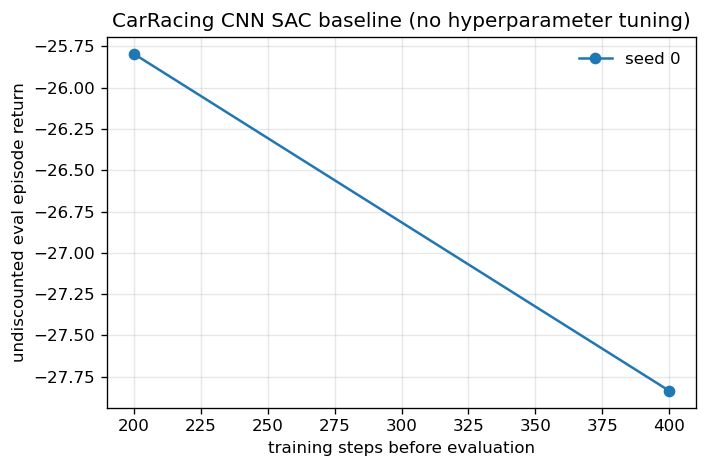

In [18]:
# Plot CarRacing CNN learning curve if data is available.
import matplotlib.pyplot as plt

if not carracing_df.empty:
    eval_only = carracing_df[carracing_df['eval_return'].notna()]
    grouped = (eval_only.groupby(['seed', 'train_step'], as_index=False)
                       .agg(eval_return=('eval_return', 'mean')))
    fig, ax = plt.subplots(figsize=(6, 4))
    for seed, sub in grouped.groupby('seed'):
        s = sub.sort_values('train_step')
        ax.plot(s['train_step'], s['eval_return'], marker='o', label=f'seed {seed}')
    ax.set_title('CarRacing CNN SAC baseline (no hyperparameter tuning)')
    ax.set_xlabel('training steps before evaluation')
    ax.set_ylabel('undiscounted eval episode return')
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    out = FIGURES_MIDWAY_DIR / 'carracing_cnn_baseline.png'
    fig.tight_layout(); fig.savefig(out, dpi=150)
    print(f'Saved {out.relative_to(REPO_ROOT)}')
    plt.show()
else:
    print('No CarRacing CNN data to plot.')

## 4. Experiment Matrix and Command Generation

The matrix is ordered to test DMC-style tasks before Car Racing and SAC/TD3 before PPO. PPO remains included because it is a required baseline.

In [19]:
@dataclass(frozen=True)
class ExperimentSpec:
    algorithm: str
    project_environment: str
    objectrl_environment: str
    seed: int
    max_steps: int
    eval_episodes: int
    eval_frequency: int
    run_mode: str

    @property
    def run_name(self) -> str:
        return f'{self.run_mode}_{self.algorithm}_{self.project_environment}_seed{self.seed}'


def build_experiment_matrix(run_mode: str = RUN_MODE) -> list[ExperimentSpec]:
    cfg = RUN_CONFIG[run_mode]
    specs: list[ExperimentSpec] = []
    for algorithm, project_env in RUN_ORDER:
        for seed in cfg['seeds']:
            specs.append(
                ExperimentSpec(
                    algorithm=algorithm,
                    project_environment=project_env,
                    objectrl_environment=OBJECTRL_ENV_NAMES[project_env],
                    seed=seed,
                    max_steps=cfg['max_steps'],
                    eval_episodes=cfg['eval_episodes'],
                    eval_frequency=cfg['eval_frequency'],
                    run_mode=run_mode,
                )
            )
    return specs


experiment_specs = build_experiment_matrix(RUN_MODE)
matrix_df = pd.DataFrame([asdict(spec) | {'run_name': spec.run_name} for spec in experiment_specs])
matrix_df

,algorithm,project_environment,objectrl_environment,seed,max_steps,eval_episodes,eval_frequency,run_mode,run_name
0,sac,cartpole_swingup,dmc-cartpole-swingup,0,1000,1,500,debug,debug_sac_cartpole_swingup_seed0
1,td3,cartpole_swingup,dmc-cartpole-swingup,0,1000,1,500,debug,debug_td3_cartpole_swingup_seed0
2,ppo,cartpole_swingup,dmc-cartpole-swingup,0,1000,1,500,debug,debug_ppo_cartpole_swingup_seed0
3,sac,acrobot_swingup,dmc-acrobot-swingup,0,1000,1,500,debug,debug_sac_acrobot_swingup_seed0
4,td3,acrobot_swingup,dmc-acrobot-swingup,0,1000,1,500,debug,debug_td3_acrobot_swingup_seed0
5,ppo,acrobot_swingup,dmc-acrobot-swingup,0,1000,1,500,debug,debug_ppo_acrobot_swingup_seed0
6,sac,car_racing_continuous,CarRacing-v3,0,1000,1,500,debug,debug_sac_car_racing_continuous_seed0
7,td3,car_racing_continuous,CarRacing-v3,0,1000,1,500,debug,debug_td3_car_racing_continuous_seed0
8,ppo,car_racing_continuous,CarRacing-v3,0,1000,1,500,debug,debug_ppo_car_racing_continuous_seed0


In [20]:
def build_objectrl_command(spec: ExperimentSpec) -> list[str]:
    # TODO_VERIFY: Confirm these CLI keys against `python objectrl/main.py --help` in a fully working environment.
    return [
        sys.executable,
        str(OBJECTRL_DIR / 'objectrl' / 'main.py'),
        '--model.name', spec.algorithm,
        '--env.name', spec.objectrl_environment,
        '--training.max_steps', str(spec.max_steps),
        '--training.eval_frequency', str(spec.eval_frequency),
        '--training.eval_episodes', str(spec.eval_episodes),
        '--logging.save_frequency', str(spec.eval_frequency),
        '--logging.result_path', str(OBJECTRL_LOG_ROOT),
        '--system.seed', str(spec.seed),
        '--system.device', DEVICE,
        '--system.storing_device', DEVICE,
    ]


def shell_join(cmd: list[str]) -> str:
    return ' '.join(shlex.quote(part) for part in cmd)


commands_df = matrix_df.copy()
commands_df['command'] = [shell_join(build_objectrl_command(spec)) for spec in experiment_specs]
commands_df[['run_name', 'algorithm', 'project_environment', 'seed', 'command']].head(12)

,run_name,algorithm,project_environment,seed,command
0,debug_sac_cartpole_swingup_seed0,sac,cartpole_swingup,0,/opt/miniconda3/envs/RL/bin/python /Users/guld...
1,debug_td3_cartpole_swingup_seed0,td3,cartpole_swingup,0,/opt/miniconda3/envs/RL/bin/python /Users/guld...
2,debug_ppo_cartpole_swingup_seed0,ppo,cartpole_swingup,0,/opt/miniconda3/envs/RL/bin/python /Users/guld...
3,debug_sac_acrobot_swingup_seed0,sac,acrobot_swingup,0,/opt/miniconda3/envs/RL/bin/python /Users/guld...
4,debug_td3_acrobot_swingup_seed0,td3,acrobot_swingup,0,/opt/miniconda3/envs/RL/bin/python /Users/guld...
5,debug_ppo_acrobot_swingup_seed0,ppo,acrobot_swingup,0,/opt/miniconda3/envs/RL/bin/python /Users/guld...
6,debug_sac_car_racing_continuous_seed0,sac,car_racing_continuous,0,/opt/miniconda3/envs/RL/bin/python /Users/guld...
7,debug_td3_car_racing_continuous_seed0,td3,car_racing_continuous,0,/opt/miniconda3/envs/RL/bin/python /Users/guld...
8,debug_ppo_car_racing_continuous_seed0,ppo,car_racing_continuous,0,/opt/miniconda3/envs/RL/bin/python /Users/guld...


## 5. Subprocess Runner, Logs, and Status Files

Each run writes a status JSON file under `results/raw/midway_poc_codex_status/`, a subprocess stdout/stderr log under `results/logs/midway_poc_codex/`, and ObjectRL's own logger outputs under `results/raw/objectrl_midway_poc_codex/` when the run actually executes.

In [21]:
def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def write_json(path: Path, data: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding='utf-8')


def run_experiment(spec: ExperimentSpec, dry_run: bool = DRY_RUN) -> dict[str, Any]:
    cmd = build_objectrl_command(spec)
    command_text = shell_join(cmd)
    run_status_dir = STATUS_ROOT / spec.run_name
    status_file = run_status_dir / 'status.json'
    subprocess_log_file = NOTEBOOK_LOGS_DIR / f'{spec.run_name}.stdout.log'
    support = classify_env_support(spec.project_environment)

    status: dict[str, Any] = {
        **asdict(spec),
        'run_name': spec.run_name,
        'command': command_text,
        'cwd': str(OBJECTRL_DIR),
        'status_file': str(status_file),
        'subprocess_log_file': str(subprocess_log_file),
        'objectrl_log_root': str(OBJECTRL_LOG_ROOT),
        'dry_run': dry_run,
        'environment_support': support,
        'status': 'not_started',
        'created_at': utc_now_iso(),
    }

    if dry_run:
        status['status'] = 'dry_run'
        write_json(status_file, status)
        return status

    if not support['execution_allowed_by_default']:
        status['status'] = 'blocked_unverified_environment'
        status['message'] = support['notes']
        write_json(status_file, status)
        return status

    env = os.environ.copy()
    env['MPLCONFIGDIR'] = str(MPLCONFIGDIR)
    env['PYTHONUNBUFFERED'] = '1'

    subprocess_log_file.parent.mkdir(parents=True, exist_ok=True)
    status['started_at'] = utc_now_iso()
    start = time.time()
    with subprocess_log_file.open('w', encoding='utf-8') as log_handle:
        process = subprocess.run(
            cmd,
            cwd=OBJECTRL_DIR,
            stdout=log_handle,
            stderr=subprocess.STDOUT,
            text=True,
            env=env,
        )
    end = time.time()

    status['finished_at'] = utc_now_iso()
    status['duration_seconds'] = round(end - start, 3)
    status['return_code'] = process.returncode
    status['status'] = 'completed' if process.returncode == 0 else 'failed'
    write_json(status_file, status)
    return status

In [22]:
all_statuses = []
for spec in experiment_specs:
    status = run_experiment(spec, dry_run=DRY_RUN)
    all_statuses.append(status)

status_df = pd.DataFrame(all_statuses)
status_csv = PROCESSED_RESULTS_DIR / f'status_{RUN_MODE}_codex.csv'
status_json = PROCESSED_RESULTS_DIR / f'status_{RUN_MODE}_codex.json'
status_df.to_csv(status_csv, index=False)
status_json.write_text(json.dumps(all_statuses, indent=2), encoding='utf-8')

print(f'Wrote {status_csv.relative_to(REPO_ROOT)}')
print(f'Wrote {status_json.relative_to(REPO_ROOT)}')
status_df[['run_name', 'algorithm', 'project_environment', 'seed', 'status', 'dry_run']]

Wrote results/processed/status_debug_codex.csv
Wrote results/processed/status_debug_codex.json


,run_name,algorithm,project_environment,seed,status,dry_run
0,debug_sac_cartpole_swingup_seed0,sac,cartpole_swingup,0,dry_run,True
1,debug_td3_cartpole_swingup_seed0,td3,cartpole_swingup,0,dry_run,True
2,debug_ppo_cartpole_swingup_seed0,ppo,cartpole_swingup,0,dry_run,True
3,debug_sac_acrobot_swingup_seed0,sac,acrobot_swingup,0,dry_run,True
4,debug_td3_acrobot_swingup_seed0,td3,acrobot_swingup,0,dry_run,True
5,debug_ppo_acrobot_swingup_seed0,ppo,acrobot_swingup,0,dry_run,True
6,debug_sac_car_racing_continuous_seed0,sac,car_racing_continuous,0,dry_run,True
7,debug_td3_car_racing_continuous_seed0,td3,car_racing_continuous,0,dry_run,True
8,debug_ppo_car_racing_continuous_seed0,ppo,car_racing_continuous,0,dry_run,True


## 6. Evaluation Return Parsing

ObjectRL writes `eval_results.npy` and `log.log` files inside timestamped run folders. The parser below first tries the NumPy artifact and then falls back to log regexes. Rows are stored as `algorithm, environment, seed, step, evaluation_return`.

In [23]:
EVAL_LOG_PATTERNS = [
    re.compile(r'EVALUATION\s+N-steps:\s*(?P<step>\d+)\s+Mean_Reward:\s*(?P<ret>-?\d+(?:\.\d+)?)', re.I),
    re.compile(r'step[:=]\s*(?P<step>\d+).*eval.*return[:=]\s*(?P<ret>-?\d+(?:\.\d+)?)', re.I),
    re.compile(r'eval.*step[:=]\s*(?P<step>\d+).*return[:=]\s*(?P<ret>-?\d+(?:\.\d+)?)', re.I),
]


def find_objectrl_run_dirs(objectrl_env_name: str, algorithm: str, seed: int) -> list[Path]:
    seed_dir = OBJECTRL_LOG_ROOT / objectrl_env_name / algorithm / f'seed_{seed:02d}'
    if not seed_dir.exists():
        return []
    return sorted([path for path in seed_dir.iterdir() if path.is_dir()])


def scalarize_reward_value(value: Any) -> float:
    if hasattr(value, 'detach'):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value, dtype=float)
    return float(np.mean(arr))


def parse_eval_results_npy(path: Path) -> list[dict[str, Any]]:
    rows = []
    try:
        data = np.load(path, allow_pickle=True).item()
    except Exception as exc:
        return [{'parse_error': f'{type(exc).__name__}: {exc}', 'source_file': str(path)}]
    if not isinstance(data, dict):
        return []
    for step, rewards in data.items():
        rows.append({
            'step': int(step),
            'evaluation_return': scalarize_reward_value(rewards),
            'source_file': str(path),
            'source_kind': 'eval_results_npy',
        })
    return rows


def parse_eval_log_file(path: Path) -> list[dict[str, Any]]:
    if not path.exists():
        return []
    rows = []
    text = path.read_text(encoding='utf-8', errors='ignore')
    for line in text.splitlines():
        for pattern in EVAL_LOG_PATTERNS:
            match = pattern.search(line)
            if match:
                rows.append({
                    'step': int(match.group('step')),
                    'evaluation_return': float(match.group('ret')),
                    'source_file': str(path),
                    'source_kind': 'log_regex',
                })
                break
    return rows


def collect_evaluation_rows(statuses: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for status in statuses:
        run_dirs = find_objectrl_run_dirs(status['objectrl_environment'], status['algorithm'], int(status['seed']))
        for run_dir in run_dirs:
            parsed_rows = []
            eval_npy = run_dir / 'eval_results.npy'
            if eval_npy.exists():
                parsed_rows.extend(parse_eval_results_npy(eval_npy))
            parsed_rows.extend(parse_eval_log_file(run_dir / 'log.log'))
            for row in parsed_rows:
                if 'parse_error' in row:
                    continue
                rows.append({
                    'algorithm': status['algorithm'],
                    'environment': status['project_environment'],
                    'environment_display': PROJECT_ENV_DISPLAY_NAMES[status['project_environment']],
                    'objectrl_environment': status['objectrl_environment'],
                    'seed': int(status['seed']),
                    'run_mode': status['run_mode'],
                    'step': int(row['step']),
                    'evaluation_return': float(row['evaluation_return']),
                    'source_file': row['source_file'],
                    'source_kind': row['source_kind'],
                })
        subprocess_log = Path(status.get('subprocess_log_file', ''))
        for row in parse_eval_log_file(subprocess_log):
            rows.append({
                'algorithm': status['algorithm'],
                'environment': status['project_environment'],
                'environment_display': PROJECT_ENV_DISPLAY_NAMES[status['project_environment']],
                'objectrl_environment': status['objectrl_environment'],
                'seed': int(status['seed']),
                'run_mode': status['run_mode'],
                'step': int(row['step']),
                'evaluation_return': float(row['evaluation_return']),
                'source_file': row['source_file'],
                'source_kind': row['source_kind'],
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(['algorithm', 'environment', 'seed', 'step', 'source_kind'])
        df = df.drop_duplicates(['algorithm', 'environment', 'seed', 'step'], keep='first')
    return df


results_df = collect_evaluation_rows(all_statuses)
results_df

""


## 7. Aggregation and CSV Export

The exported CSV files are report-facing inputs. If `DRY_RUN=True`, they may be empty except for run status.

In [24]:
if results_df.empty:
    summary_df = pd.DataFrame(columns=['algorithm', 'environment', 'environment_display', 'step', 'mean_return', 'std_return', 'n_seeds'])
else:
    summary_df = (
        results_df
        .groupby(['algorithm', 'environment', 'environment_display', 'step'], as_index=False)
        .agg(
            mean_return=('evaluation_return', 'mean'),
            std_return=('evaluation_return', 'std'),
            n_seeds=('seed', 'nunique'),
        )
        .sort_values(['environment', 'algorithm', 'step'])
    )

returns_csv = PROCESSED_RESULTS_DIR / f'evaluation_returns_{RUN_MODE}_codex.csv'
summary_csv = PROCESSED_RESULTS_DIR / f'evaluation_summary_{RUN_MODE}_codex.csv'
results_df.to_csv(returns_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print(f'Wrote {returns_csv.relative_to(REPO_ROOT)} with {len(results_df)} rows')
print(f'Wrote {summary_csv.relative_to(REPO_ROOT)} with {len(summary_df)} rows')
summary_df

Wrote results/processed/evaluation_returns_debug_codex.csv with 0 rows
Wrote results/processed/evaluation_summary_debug_codex.csv with 0 rows


,algorithm,environment,environment_display,step,mean_return,std_return,n_seeds


## 8. Learning-Curve Figure Export

The required figure format is one subpanel per environment, x-axis as training steps before evaluation, y-axis as undiscounted evaluation episode return, and one curve per algorithm. The function saves to `figures/midway/`.

In [25]:
def plot_learning_curves(summary: pd.DataFrame, output_prefix: Path) -> None:
    if summary.empty:
        print('No evaluation rows available yet. Run experiments or parse existing ObjectRL logs before plotting.')
        return

    environments = [env for env in PROJECT_ENVIRONMENTS if env in set(summary['environment'])]
    if not environments:
        environments = list(summary['environment'].drop_duplicates())

    fig, axes = plt.subplots(1, len(environments), figsize=(5.0 * len(environments), 4.0), sharey=False)
    if len(environments) == 1:
        axes = [axes]

    colors = {'ppo': '#4C78A8', 'sac': '#F58518', 'td3': '#54A24B'}
    for ax, env_name in zip(axes, environments):
        env_df = summary[summary['environment'] == env_name]
        for algorithm in ALGORITHMS:
            alg_df = env_df[env_df['algorithm'] == algorithm].sort_values('step')
            if alg_df.empty:
                continue
            ax.plot(
                alg_df['step'],
                alg_df['mean_return'],
                label=algorithm.upper(),
                color=colors.get(algorithm),
                linewidth=2,
            )
            if alg_df['std_return'].notna().any() and (alg_df['n_seeds'] > 1).any():
                std = alg_df['std_return'].fillna(0.0)
                lower = alg_df['mean_return'] - std
                upper = alg_df['mean_return'] + std
                ax.fill_between(alg_df['step'], lower, upper, color=colors.get(algorithm), alpha=0.18, linewidth=0)
        ax.set_title(PROJECT_ENV_DISPLAY_NAMES.get(env_name, env_name))
        ax.set_xlabel('Training steps before evaluation')
        ax.set_ylabel('Undiscounted evaluation episode return')
        ax.legend(frameon=False)

    fig.tight_layout()
    pdf_path = output_prefix.with_suffix('.pdf')
    png_path = output_prefix.with_suffix('.png')
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, bbox_inches='tight')
    plt.show()
    print(f'Saved {pdf_path.relative_to(REPO_ROOT)}')
    print(f'Saved {png_path.relative_to(REPO_ROOT)}')


plot_learning_curves(summary_df, FIGURES_MIDWAY_DIR / f'midway_baselines_{RUN_MODE}_codex')
plot_learning_curves(summary_df, FIGURES_MIDWAY_DIR / 'midway_baselines')

No evaluation rows available yet. Run experiments or parse existing ObjectRL logs before plotting.
No evaluation rows available yet. Run experiments or parse existing ObjectRL logs before plotting.


## 9. Report-Facing Notes

Use this section to transfer reproducibility details and honest interim status into the midway report. Do not present dry-run outputs as experimental results.

In [26]:
def format_run_status_notes(status: pd.DataFrame) -> str:
    counts = status.groupby(["algorithm", "project_environment", "status"]).size().reset_index(name="n_runs")
    lines = [
        "Midway baseline protocol notes",
        "",
        f"- Runtime mode: {RUN_MODE}",
        f"- Dry run: {DRY_RUN}",
        f"- Algorithms: {', '.join(alg.upper() for alg in ALGORITHMS)}",
        f"- Seeds requested in this mode: {RUN_CONFIG[RUN_MODE]['seeds']}",
        f"- Max training steps: {RUN_CONFIG[RUN_MODE]['max_steps']}",
        f"- Evaluation episodes: {RUN_CONFIG[RUN_MODE]['eval_episodes']}",
        f"- Evaluation frequency: {RUN_CONFIG[RUN_MODE]['eval_frequency']} training steps",
        "- Metric: undiscounted evaluation episode return.",
        "- Implementation source: ObjectRL PPO, SAC, and TD3; no baseline algorithm is reimplemented here.",
        "- Local device policy: ObjectRL CLI runs on CPU with `--system.device=cpu --system.storing_device=cpu`. PyTorch reports MPS available, but ObjectRL CLI rejects `mps`.",
        "- ObjectRL CPU smoke test on `dmc-cheetah-run` works (Section 3b.2; opt-in).",
        "- Official project-environment adapter (`scripts/project_envs.py`) works for all three required envs (`car_racing_continuous`, `cartpole_swingup`, `acrobot_swingup`); `external/objectrl/` and `external/Gymnasium/` are unmodified.",
        "- Project-side runner `scripts/run_project_objectrl_baseline.py` drives ObjectRL's `ControlExperiment` against the project envs via a runtime monkey-patch of `objectrl.experiments.base_experiment.make_env` (Section 3d).",
        "- Small real **debug** training has completed for PPO, SAC, and TD3 on `cartpole_swingup` and `acrobot_swingup` (seed 0, max 1000 steps, eval_episodes=1, CPU). CSVs in `results/processed/project_baselines/`. These are pipeline-verification runs, not midway or final performance claims.",
        "- CarRacing real training is intentionally **deferred**: `(96, 96, 3)` uint8 image observations require a CNN policy or feature/flatten preprocessing before ObjectRL's default MLP actor/critic apply.",
        "- PPO integration constraint: ObjectRL asserts `training.learn_frequency > 1` when `normalize_advantages=True` and uses no warmup. The runner enforces `--warmup-steps 0` and defaults `learn_frequency=256` for PPO automatically.",
        "",
        "Environment verification status:",
    ]
    for row in env_support_df.to_dict("records"):
        lines.append(f"- {row['display_name']}: ObjectRL name `{row['objectrl_env_name']}`; {row['notes']}.")
    lines.extend(["", "Run status counts:"])
    for row in counts.to_dict("records"):
        env_display = PROJECT_ENV_DISPLAY_NAMES[row["project_environment"]]
        lines.append(f"- {row['algorithm'].upper()} / {env_display} / {row['status']}: {row['n_runs']}")
    lines.extend([
        "",
        "Figure caption draft:",
        "Interim baseline learning curves for PPO, SAC, and TD3. The x-axis shows the number of online training steps before evaluation, and the y-axis shows undiscounted evaluation episode return. Curves average over available seeds; shaded regions indicate one standard deviation when multiple seeds are available. Dry-run or incomplete runs should be labelled as pipeline validation rather than final empirical evidence.",
    ])
    return "\n".join(lines)


notes = format_run_status_notes(status_df)
notes_path = PROCESSED_RESULTS_DIR / f"report_notes_{RUN_MODE}_codex.md"

notes_path.write_text(notes, encoding="utf-8")
print(f"\nWrote {notes_path.relative_to(REPO_ROOT)}")
print(notes)



Wrote results/processed/report_notes_debug_codex.md
Midway baseline protocol notes

- Runtime mode: debug
- Dry run: True
- Algorithms: PPO, SAC, TD3
- Seeds requested in this mode: [0]
- Max training steps: 1000
- Evaluation episodes: 1
- Evaluation frequency: 500 training steps
- Metric: undiscounted evaluation episode return.
- Implementation source: ObjectRL PPO, SAC, and TD3; no baseline algorithm is reimplemented here.
- Local device policy: ObjectRL CLI runs on CPU with `--system.device=cpu --system.storing_device=cpu`. PyTorch reports MPS available, but ObjectRL CLI rejects `mps`.
- ObjectRL CPU smoke test on `dmc-cheetah-run` works (Section 3b.2; opt-in).
- Official project-environment adapter (`scripts/project_envs.py`) works for all three required envs (`car_racing_continuous`, `cartpole_swingup`, `acrobot_swingup`); `external/objectrl/` and `external/Gymnasium/` are unmodified.
- Project-side runner `scripts/run_project_objectrl_baseline.py` drives ObjectRL's `ControlExper

## 10. Next Verification Steps

1. **Implement the project-side ObjectRL runner.** `scripts/run_project_objectrl_baseline.py` is wired up to the point of `NotImplementedError`. Finish it by either subclassing `ControlExperiment` to override env construction or by building `MainConfig` + `get_model(...)` and driving the loop directly. ObjectRL CLI cannot be used directly because `make_env.py` whitelists env names (verified).
2. **Car Racing observations.** `CarRacing-v3` returns `(96,96,3)` uint8 images. ObjectRL's default agents assume 1-D `Box` observations, so this env needs a CNN policy or a feature/flatten wrapper before SAC/TD3/PPO can train.
3. **Local device policy.** Keep `--system.device=cpu --system.storing_device=cpu` for all local debug/midway runs. PyTorch MPS is available but ObjectRL CLI rejects it; do not patch ObjectRL.
4. **Inspect ObjectRL outputs** (`log.log`, `eval_results.npy`) once real runs exist and update the parser if the active version's logging format differs.
5. **Promote to midway** by switching `RUN_MODE = 'midway'`, keeping seeds `0..4`, and exporting `results/processed/*_midway_codex.csv` plus `figures/midway/midway_baselines.*` for the report — only after step 1 produces real evaluation rows.